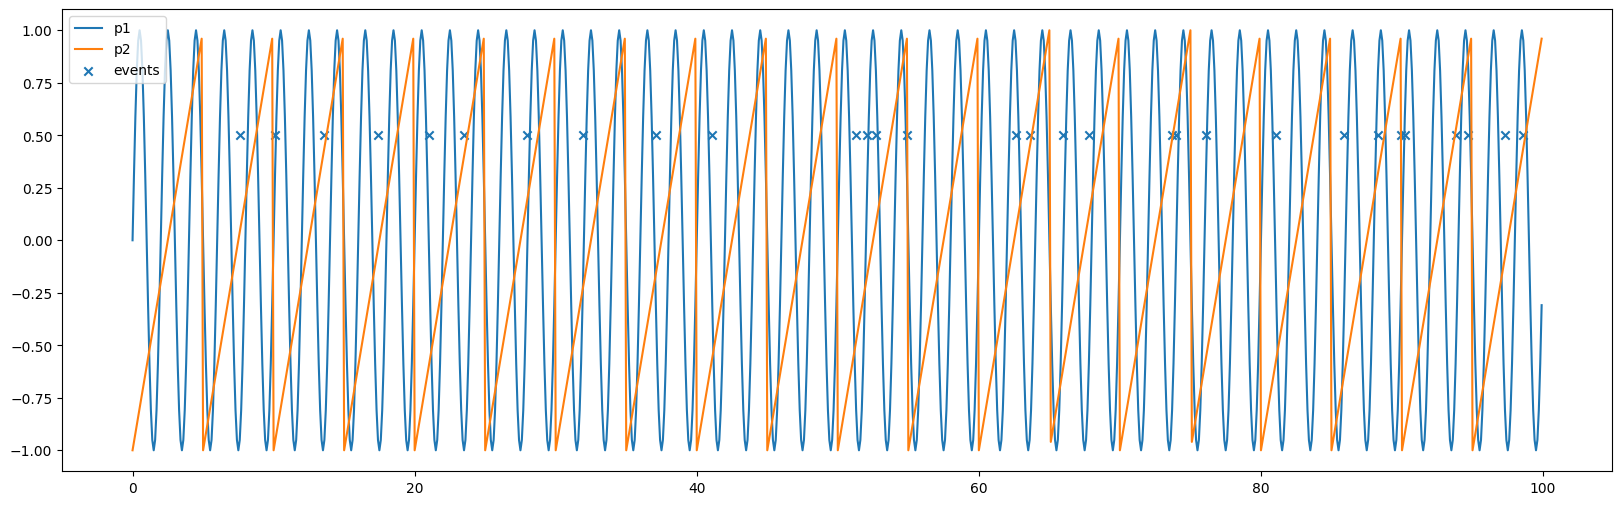

True CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
beta0, beta1, beta2, beta3 = [-0.84843715 -0.27014405  0.11551499 -0.28933153]
负对数似然 = 64.86474424527017


/var/folders/j8/n1gsp0cx3yn8tx6shhgnrzdm0000gn/T/ipykernel_28858/766435020.py:68: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(lambda_t, t)


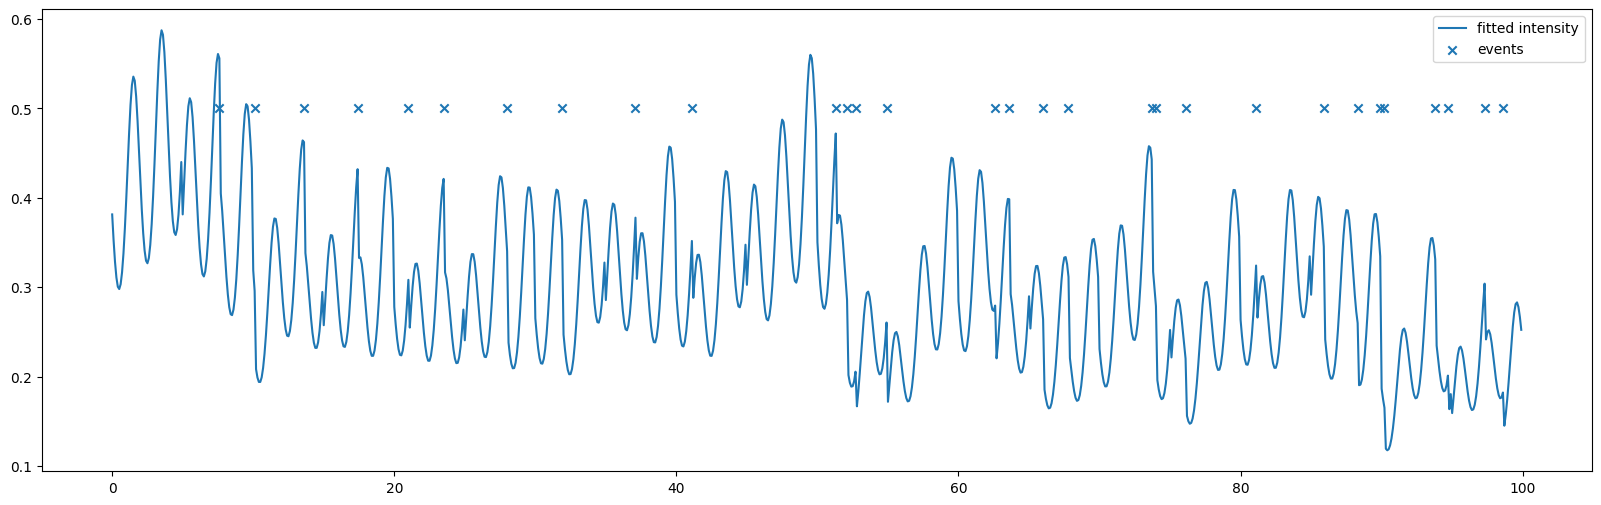

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from scipy.optimize import minimize

np.random.seed(42)

t = np.arange(0, 100, 0.1)

# 随机选 30 个事件时刻
n_events = 30
random_indices = np.random.choice(t.shape[0], n_events, replace=False)
events = np.sort(t[random_indices])

# 两个协变量
p1 = np.sin(np.pi * t)
p2 = signal.sawtooth(2 * np.pi * t / 5)

plt.figure(figsize=(20, 6))
plt.plot(t, p1, label="p1")
plt.plot(t, p2, label="p2")
plt.scatter(events, np.ones_like(events) * 0.5, marker="x", label="events")
plt.legend()
plt.show()

# 注意：tau=0.01 太小，事件间隔通常远大于 0.01，
# exp(-间隔/0.01) 会几乎全是 0，H 基本没有信息。
# 这里先改成 5，你可以根据研究问题调整。
tau = 5.0

# 1) 事件时刻的历史影响 H_events
# H_events[i] = sum_{j < i} exp(-(events[i] - events[j]) / tau)
H_events = np.zeros(len(events))
for i in range(1, len(events)):
    H_events[i] = np.sum(np.exp(-(events[i] - events[:i]) / tau))

# 2) 连续时间网格上的历史影响 H_t
# H_t[k] = sum_{event_j < t[k]} exp(-(t[k] - event_j) / tau)
H_t = np.zeros_like(t)
for e in events:
    mask = t > e
    H_t[mask] += np.exp(-(t[mask] - e) / tau)

# 3) 取出事件时刻对应的 p1, p2
event_idx = np.searchsorted(t, events)
p1_events = p1[event_idx]
p2_events = p2[event_idx]


def neg_log_likelihood(beta, t, p1, p2, H_t,
                       p1_events, p2_events, H_events):
    beta0, beta1, beta2, beta3 = beta

    # 事件时刻的 lambda
    eta_events = beta0 + beta1 * p1_events + beta2 * p2_events + beta3 * H_events
    # 连续时间上的 lambda，用于积分
    eta_t = beta0 + beta1 * p1 + beta2 * p2 + beta3 * H_t

    # 防止 exp 溢出
    # eta_events = np.clip(eta_events, -50, 50)
    # eta_t = np.clip(eta_t, -50, 50)

    lambda_events = np.exp(eta_events)
    lambda_t = np.exp(eta_t)

    # 连续时间点过程负对数似然：
    # - sum log lambda(t_i) + integral lambda(t) dt
    integral = np.trapz(lambda_t, t)
    nll = -np.sum(np.log(lambda_events)) + integral

    return nll


x0 = [0.0, 0.0, 0.0, 0.0]
bounds = [(-10, 10)] * 4

res = minimize(
    neg_log_likelihood,
    x0,
    args=(t, p1, p2, H_t, p1_events, p2_events, H_events),
    method='L-BFGS-B',
    bounds=bounds
)

print(res.success, res.message)
print("beta0, beta1, beta2, beta3 =", res.x)
print("负对数似然 =", res.fun)

# plot events and fitted intensity
beta0, beta1, beta2, beta3 = res.x
eta_t = beta0 + beta1 * p1 + beta2 * p2 + beta3 * H_t
# eta_t = np.clip(eta_t, -50, 50)
lambda_t = np.exp(eta_t)

plt.figure(figsize=(20, 6))
plt.plot(t, lambda_t, label="fitted intensity")
plt.scatter(events, np.ones_like(events) * 0.5, marker="x", label="events")
plt.legend()
plt.show()

In [18]:
#!/usr/bin/env python3
"""Barker 2011 SpeleoAge events: continuous-time fit and definition sensitivity.

Variable-threshold events are primary; fixed-threshold events are a nominal-age
sensitivity. Both report nominal LR p here; their BG-model bootstrap calibrations
are separate experiments. Both use inhibitory exponential history with tau =
1.5 kyr and condition on their exact oldest event. SpeleoAge is retained numerically under
the BP1950 working assumption; its precise source epoch remains unverified.
"""

import argparse
from pathlib import Path
import sys
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


ROOT = Path("/Users/pz/VScode/MCV_ORB")
sys.path.insert(0, str(ROOT.parent))
from toolbox import event_model, model_stats
from toolbox.point_process import fit_point_process
from toolbox.plotting import (
    configure_barker_style, format_phase_response_axis, mark_preferred_phase,
)
from toolbox.project_config import (
    PROJECT_ROOT, BARKER_EVENT_CSVS, CATALOGUE_COLORS, MODEL_VERSION,
    LR04_CSV, CO2_CSV, ORBITAL_CSV, PRECESSION_PHASE_CSV,
)

RUN_NAME = "Barker2011_event_phase_analysis"
OUT_DATA_DIR = ROOT / "data/processed" / RUN_NAME
OUT_FIG_DIR = ROOT / "figures" / RUN_NAME
EXPECTED_COUNTS = {"variable_threshold": 70, "fixed_threshold": 59}
DEFINITION_COLORS = {"variable_threshold": CATALOGUE_COLORS["variable"],
                     "fixed_threshold": CATALOGUE_COLORS["fixed"]}
EVENT_COLOR = DEFINITION_COLORS["variable_threshold"]
ANALYSIS_START_KA, ANALYSIS_END_KA = 0.0, 400.0
HISTORY_TAU_KA = 1.5
HISTORY_TERM = "same_type_exponential_history"

events = pd.read_csv(BARKER_EVENT_CSVS["variable_threshold"], float_precision="round_trip")
events["segment_id"] = "Barker2011"

events

,event_id,event_age_kyr_bp,segment_id
0,Barker_S3_010,11.402408,Barker2011
1,Barker_S3_011,14.572905,Barker2011
2,Barker_S3_012,27.979391,Barker2011
3,Barker_S3_013,29.831152,Barker2011
4,Barker_S3_014,32.919723,Barker2011
...,...,...,...
65,Barker_S3_075,372.804463,Barker2011
66,Barker_S3_076,378.190563,Barker2011
67,Barker_S3_077,387.378117,Barker2011
68,Barker_S3_078,392.245696,Barker2011
